# Notebook 7: Model Comparison

**Objective:** Aggregate results from all baseline ML models and GNN models into a single comparison table and produce paper-ready figures.

In [1]:
import sys
sys.path.append('../src')

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from graph_builder import load_graph
from models import GCN, GraphSAGE, GAT
from evaluate import evaluate_model, build_comparison_table
from utils import set_seed, get_device, load_model
from sklearn.metrics import roc_curve, precision_recall_curve

set_seed(42)
device = get_device()
sns.set_theme(style='whitegrid')
%matplotlib inline

C:\Users\anmol\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\anmol\AppData\Local\Programs\Python\Python310\Lib\site-packages\torch_scatter\_version_cpu.pyd
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
C:\Users\anmol\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\anmol\AppData\Local\Programs\Python\Python310\Lib\site-packages\torch_sparse\_version_cpu.pyd
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


In [2]:
data = load_graph('../data/processed')

## 1. Load Trained GNN Models and Collect Metrics

In [3]:
gnn_configs = [
    ('GCN',       GCN(data.num_features, 64, 2),         '../models/gcn_model.pt'),
    ('GraphSAGE', GraphSAGE(data.num_features, 64, 2),   '../models/graphsage_model.pt'),
    ('GAT',       GAT(data.num_features, 32, 2, heads=4),'../models/gat_model.pt'),
]

gnn_results  = {}
gnn_probs    = {}

for name, model, path in gnn_configs:
    model = load_model(model, path, device)
    res   = evaluate_model(model, data, data.test_mask, device)
    gnn_results[name] = {
        'accuracy' : (res['y_pred'] == res['y_true']).mean(),
        'precision': __import__('sklearn.metrics',fromlist=['precision_score']).precision_score(res['y_true'],res['y_pred'],zero_division=0),
        'recall'   : __import__('sklearn.metrics',fromlist=['recall_score']).recall_score(res['y_true'],res['y_pred'],zero_division=0),
        'f1'       : __import__('sklearn.metrics',fromlist=['f1_score']).f1_score(res['y_true'],res['y_pred'],zero_division=0),
        'roc_auc'  : res['roc_auc'],
        'pr_auc'   : res['pr_auc'],
    }
    gnn_probs[name] = (res['y_true'], res['y_prob'])

              precision    recall  f1-score   support

       Licit       0.99      0.91      0.95      8404
     Illicit       0.51      0.90      0.65       909

    accuracy                           0.91      9313
   macro avg       0.75      0.90      0.80      9313
weighted avg       0.94      0.91      0.92      9313

ROC-AUC : 0.9648
PR-AUC  : 0.8098


              precision    recall  f1-score   support

       Licit       0.99      0.94      0.96      8404
     Illicit       0.62      0.90      0.73       909

    accuracy                           0.94      9313
   macro avg       0.80      0.92      0.85      9313
weighted avg       0.95      0.94      0.94      9313

ROC-AUC : 0.9770
PR-AUC  : 0.8995


              precision    recall  f1-score   support

       Licit       0.99      0.87      0.93      8404
     Illicit       0.43      0.95      0.60       909

    accuracy                           0.87      9313
   macro avg       0.71      0.91      0.76      9313
weighted avg       0.94      0.87      0.89      9313

ROC-AUC : 0.9759
PR-AUC  : 0.8681


## 2. Load Baseline Results

In [4]:
try:
    baseline_df = pd.read_csv('../results/baseline_metrics.csv', index_col=0)
    baseline_results = baseline_df.to_dict(orient='index')
    print('Baseline results loaded.')
except FileNotFoundError:
    print('Run notebook 03 first to generate baseline_metrics.csv')
    baseline_results = {}

Baseline results loaded.

## 3. Full Comparison Table

In [5]:
all_results = {**baseline_results, **gnn_results}
df_compare  = build_comparison_table(all_results, save_path='../results/comparison_table.csv')

                     accuracy  precision  recall      f1  roc_auc  pr_auc
Model                                                                    
Logistic Regression    0.8783     0.4414  0.9285  0.5984   0.9649  0.7546
Random Forest          0.9875     0.9962  0.8757  0.9321   0.9966  0.9817
XGBoost                0.9928     0.9930  0.9329  0.9620   0.9974  0.9872
LightGBM               0.9927     0.9873  0.9373  0.9616   0.9982  0.9895
MLP                    0.9811     0.9379  0.8636  0.8992   0.9856  0.9408
GCN                    0.9069     0.5132  0.8955  0.6525   0.9648  0.8098
GraphSAGE              0.9358     0.6175  0.8988  0.7321   0.9770  0.8995
GAT                    0.8743     0.4342  0.9516  0.5963   0.9759  0.8681
Saved to ../results/comparison_table.csv


## 4. Bar Chart: F1, ROC-AUC, PR-AUC

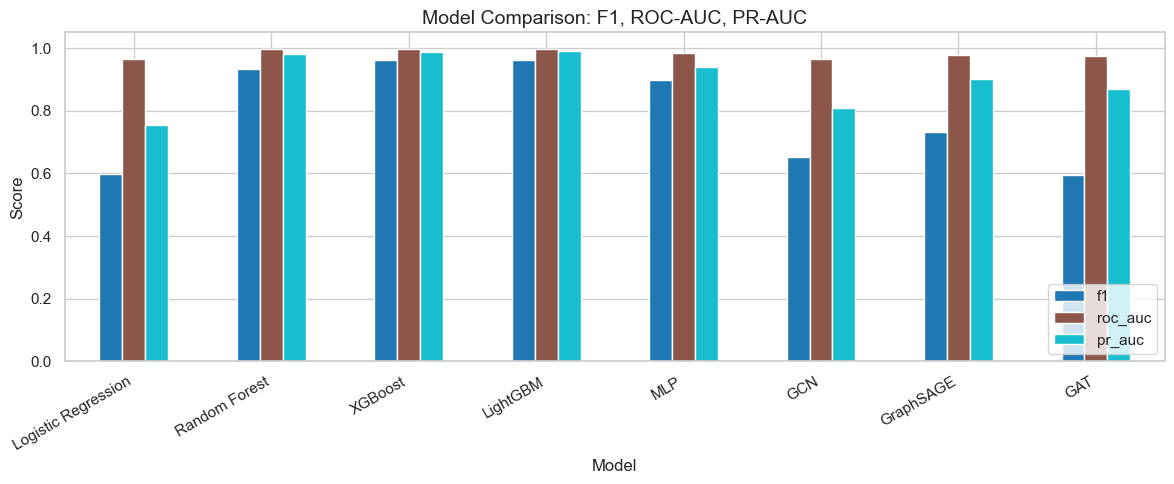

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
df_compare[['f1','roc_auc','pr_auc']].plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Model Comparison: F1, ROC-AUC, PR-AUC', fontsize=14)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/full_model_comparison.png', dpi=150)
plt.show()

## 5. Combined ROC Curves for GNN Models

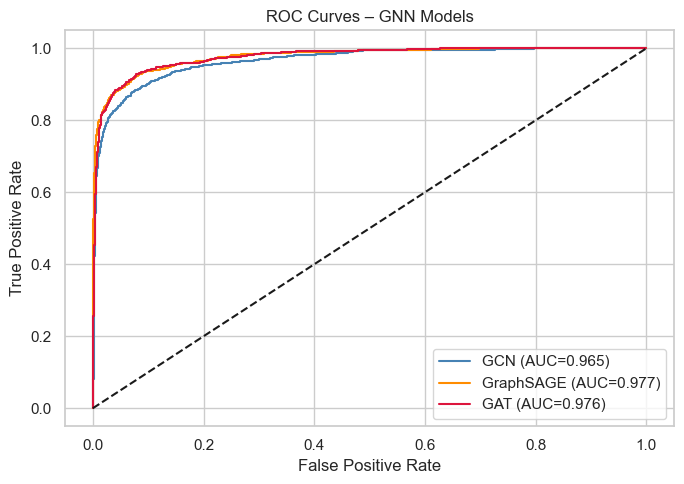

In [7]:
plt.figure(figsize=(7, 5))
colors = ['steelblue', 'darkorange', 'crimson']
for (name, (y_true, y_prob)), color in zip(gnn_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    from sklearn.metrics import roc_auc_score
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – GNN Models')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/gnn_roc_curves.png', dpi=150)
plt.show()

## 6. Combined PR Curves for GNN Models

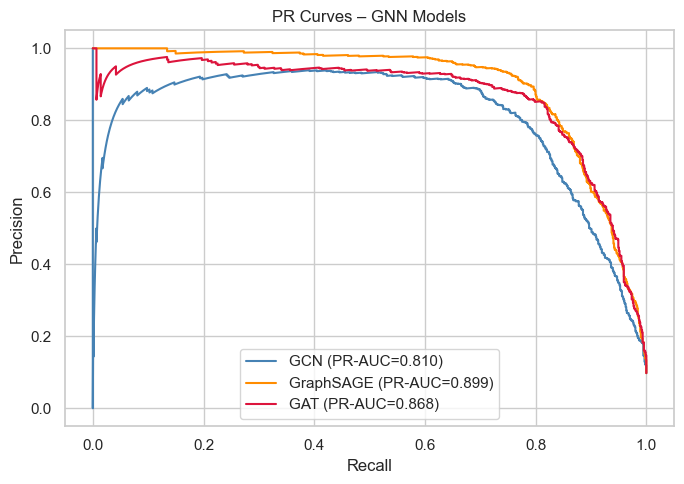

In [8]:
plt.figure(figsize=(7, 5))
from sklearn.metrics import average_precision_score
for (name, (y_true, y_prob)), color in zip(gnn_probs.items(), colors):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    plt.plot(recall, precision, label=f'{name} (PR-AUC={pr_auc:.3f})', color=color)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curves – GNN Models')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/gnn_pr_curves.png', dpi=150)
plt.show()